# 25 — Analyze Hyperalignment Results (Smorgasbord Atlas)

Loads pre-saved arrays from `24_hyperalignment_smor_saving.py` — no raw NIfTI data needed.
1. ISC across all 5 subjects before and after alignment
2. Left-out subject score before and after alignment
3. Structured access to aligned data by task/contrast/encounter

In [1]:
import sys
import pickle
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from nilearn.maskers import NiftiMasker
from nilearn.image import math_img, resample_to_img
from nilearn import plotting
from itertools import combinations
from scipy.stats import pearsonr

sys.path.insert(0, str(Path.cwd()))
from utils import SUBJECTS

/oak/stanford/groups/russpold/users/nklevak/network_second_modeling/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 3.2.1'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
ANALYSIS_DIR     = Path.cwd()
ALIGN_DIR        = ANALYSIS_DIR / "hyperalignment_fmralign_results" / "discovery_sample" / "smorgasbord_parcels"
SAVE_DIR         = ALIGN_DIR / "saved_arrays"

train_subjects   = SUBJECTS[:-1]
left_out_subject = SUBJECTS[-1]
print(f"Training subjects: {train_subjects}")
print(f"Left-out subject:  {left_out_subject}")

Training subjects: ['sub-s03', 'sub-s10', 'sub-s19', 'sub-s29']
Left-out subject:  sub-s43


In [3]:
# Load pre-saved masked and aligned arrays (no raw NIfTIs needed)
masked_all  = {s: np.load(SAVE_DIR / f"masked_{s}.npy")  for s in SUBJECTS}
aligned_all = {s: np.load(SAVE_DIR / f"aligned_{s}.npy") for s in SUBJECTS}

with open(SAVE_DIR / "shared_tce_sorted.pkl", "rb") as f:
    shared_tce_sorted = pickle.load(f)

with open(SAVE_DIR / "pair_labels.pkl", "rb") as f:
    pair_labels = pickle.load(f)

print(f"Shared tuples: {len(shared_tce_sorted)}")
print(f"Array shape per subject: {masked_all[SUBJECTS[0]].shape}  (n_contrasts x n_voxels)")

Shared tuples: 159
Array shape per subject: (159, 172463)  (n_contrasts x n_voxels)


In [4]:
# Masker needed only for inverse_transform (plotting) — must match 23/24 smorgasbord mask.
# Load atlas NIfTI directly (avoids stale path in pickled Bunch object).
SMOR_ATLAS_NII = ANALYSIS_DIR / "smorgasbord_atlas_files" / "tpl-MNI152NLin2009cAsym_res-01_atlas-smorgasbord_dseg.nii"
ref_nii = nib.load(SAVE_DIR / "isc_before_mean.nii.gz")
atlas_resampled = resample_to_img(
    nib.load(SMOR_ATLAS_NII), ref_nii,
    interpolation="nearest", force_resample=True, copy_header=True,
)
mask_img = math_img("atlas > 0", atlas=atlas_resampled)
masker = NiftiMasker(mask_img=mask_img).fit()
print(f"Mask covers {masker.mask_img_.get_fdata().sum():.0f} voxels")

Mask covers 172463 voxels


## 1. Pairwise ISC before and after alignment

In [5]:
isc_before_mean  = np.load(SAVE_DIR / "isc_before_mean.npy")
isc_after_mean   = np.load(SAVE_DIR / "isc_after_mean.npy")
isc_before_pairs = np.load(SAVE_DIR / "isc_before_pairs.npy")
isc_after_pairs  = np.load(SAVE_DIR / "isc_after_pairs.npy")

before_means = isc_before_pairs.mean(axis=1)
after_means  = isc_after_pairs.mean(axis=1)

print(f"Overall mean ISC before: {isc_before_mean.mean():.4f}")
print(f"Overall mean ISC after:  {isc_after_mean.mean():.4f}")
print()
for (s1, s2), b, a in zip(pair_labels, before_means, after_means):
    print(f"  {s1} x {s2}: before={b:.3f}  after={a:.3f}  Δ={a-b:+.3f}")

Overall mean ISC before: 0.1425
Overall mean ISC after:  0.5556

  sub-s03 x sub-s10: before=0.126  after=0.557  Δ=+0.431
  sub-s03 x sub-s19: before=0.171  after=0.549  Δ=+0.378
  sub-s03 x sub-s29: before=0.234  after=0.598  Δ=+0.364
  sub-s03 x sub-s43: before=0.146  after=0.562  Δ=+0.416
  sub-s10 x sub-s19: before=0.075  after=0.528  Δ=+0.453
  sub-s10 x sub-s29: before=0.167  after=0.563  Δ=+0.396
  sub-s10 x sub-s43: before=0.107  after=0.577  Δ=+0.470
  sub-s19 x sub-s29: before=0.156  after=0.542  Δ=+0.386
  sub-s19 x sub-s43: before=0.086  after=0.514  Δ=+0.428
  sub-s29 x sub-s43: before=0.156  after=0.566  Δ=+0.410


/tmp/ipykernel_9550/2780117063.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


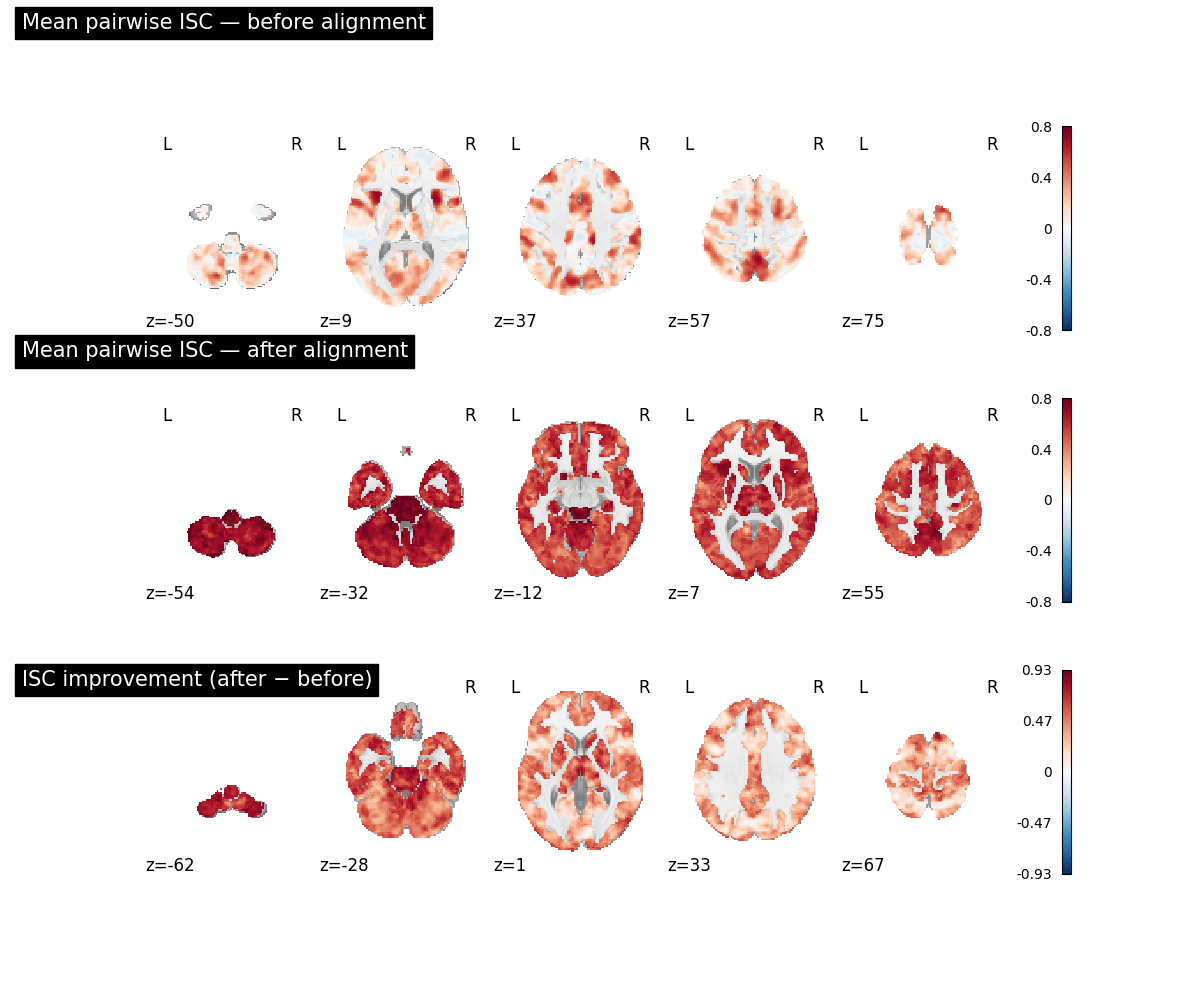

In [6]:
isc_before_img = nib.load(SAVE_DIR / "isc_before_mean.nii.gz")
isc_after_img  = nib.load(SAVE_DIR / "isc_after_mean.nii.gz")
isc_diff_img   = nib.load(SAVE_DIR / "isc_diff.nii.gz")

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
plotting.plot_stat_map(
    isc_before_img, display_mode="z", cut_coords=5, vmax=0.8,
    title="Mean pairwise ISC — before alignment", axes=axes[0], colorbar=True
)
plotting.plot_stat_map(
    isc_after_img, display_mode="z", cut_coords=5, vmax=0.8,
    title="Mean pairwise ISC — after alignment", axes=axes[1], colorbar=True
)
plotting.plot_stat_map(
    isc_diff_img, display_mode="z", cut_coords=5,
    title="ISC improvement (after − before)", axes=axes[2], colorbar=True
)
plt.tight_layout()
plt.savefig(ALIGN_DIR / "isc_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

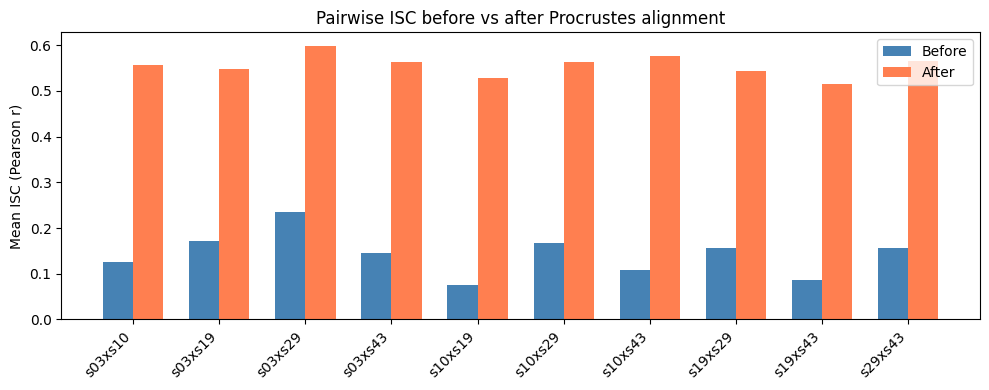

In [7]:
pair_tick_labels = [f"{s1[-3:]}x{s2[-3:]}" for s1, s2 in pair_labels]
x = np.arange(len(pair_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, before_means, w, label='Before', color='steelblue')
ax.bar(x + w/2, after_means,  w, label='After',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(pair_tick_labels, rotation=45, ha='right')
ax.set_ylabel('Mean ISC (Pearson r)')
ax.set_title('Pairwise ISC before vs after Procrustes alignment')
ax.legend()
plt.tight_layout()
plt.savefig(ALIGN_DIR / "isc_pairwise_bar.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Left-out subject: score before vs after alignment

Left-out subject (sub-s43)
  Mean score before alignment: 0.1881
  Mean score after  alignment: 0.6703


/tmp/ipykernel_9550/3155860506.py:12: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(
/tmp/ipykernel_9550/3155860506.py:17: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(
/tmp/ipykernel_9550/3155860506.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


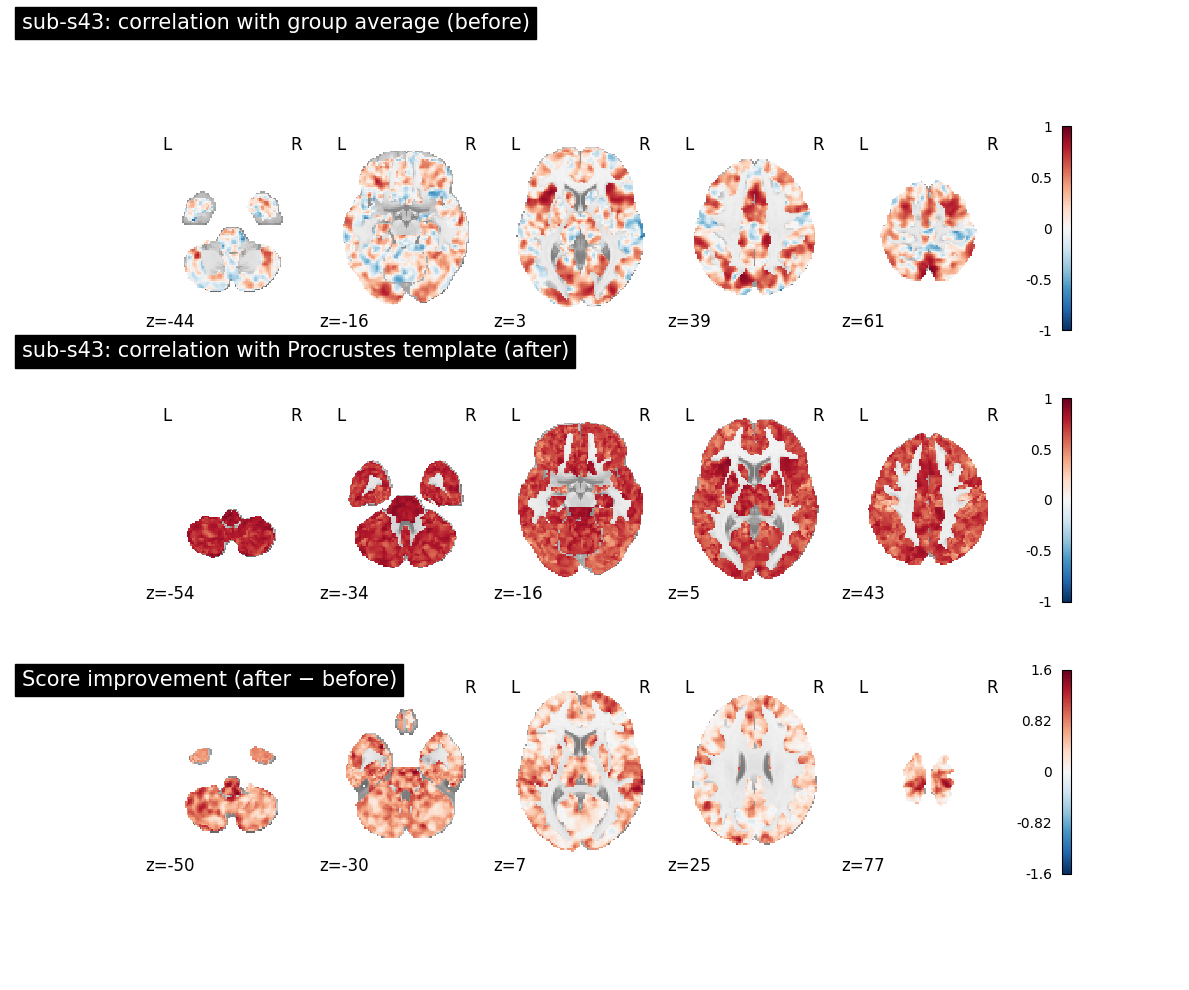

In [8]:
average_score_img  = nib.load(ALIGN_DIR / "average_score.nii.gz")
template_score_img = nib.load(ALIGN_DIR / "template_score.nii.gz")

avg_score  = np.nan_to_num(masker.transform(average_score_img).squeeze())
tmpl_score = np.nan_to_num(masker.transform(template_score_img).squeeze())

print(f"Left-out subject ({left_out_subject})")
print(f"  Mean score before alignment: {avg_score.mean():.4f}")
print(f"  Mean score after  alignment: {tmpl_score.mean():.4f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
plotting.plot_stat_map(
    average_score_img, display_mode="z", cut_coords=5, vmax=1,
    title=f"{left_out_subject}: correlation with group average (before)",
    axes=axes[0], colorbar=True
)
plotting.plot_stat_map(
    template_score_img, display_mode="z", cut_coords=5, vmax=1,
    title=f"{left_out_subject}: correlation with Procrustes template (after)",
    axes=axes[1], colorbar=True
)
diff_img = masker.inverse_transform(tmpl_score - avg_score)
plotting.plot_stat_map(
    diff_img, display_mode="z", cut_coords=5,
    title="Score improvement (after − before)",
    axes=axes[2], colorbar=True
)
plt.tight_layout()
plt.savefig(ALIGN_DIR / "left_out_score_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Structured access by task / contrast / encounter

Useful for practice effects analysis — access aligned activation maps per subject/task/contrast/encounter.

In [9]:
# structured[subject][task][contrast][encounter] → (n_voxels,) array
structured = {}
for subj in SUBJECTS:
    structured[subj] = defaultdict(lambda: defaultdict(dict))
    for i, (task, contrast, enc) in enumerate(shared_tce_sorted):
        structured[subj][task][contrast][enc] = aligned_all[subj][i]

# Example: practice effects for nBack / twoBack-oneBack across encounters
task, contrast = 'nBack', 'twoBack-oneBack'
encs = sorted(structured[SUBJECTS[0]][task][contrast].keys())
print(f"Available encounters for {task}/{contrast}: {encs}")
print(f"Shape of one map: {structured[SUBJECTS[0]][task][contrast][encs[0]].shape}")

Available encounters for nBack/twoBack-oneBack: ['01', '02', '03', '04', '05']
Shape of one map: (172463,)


In [10]:
print("=== Summary ===")
print(f"Subjects: {SUBJECTS}")
print(f"Left-out: {left_out_subject}")
print(f"Shared contrasts x encounters: {len(shared_tce_sorted)}")
print()
print(f"Pairwise ISC before: {before_means.mean():.4f} ± {before_means.std():.4f}")
print(f"Pairwise ISC after:  {after_means.mean():.4f} ± {after_means.std():.4f}")
print()
print(f"Left-out score before: {avg_score.mean():.4f}")
print(f"Left-out score after:  {tmpl_score.mean():.4f}")

=== Summary ===
Subjects: ['sub-s03', 'sub-s10', 'sub-s19', 'sub-s29', 'sub-s43']
Left-out: sub-s43
Shared contrasts x encounters: 159

Pairwise ISC before: 0.1425 ± 0.0441
Pairwise ISC after:  0.5556 ± 0.0227

Left-out score before: 0.1881
Left-out score after:  0.6703


## 4. Practice effects across encounters

Two analyses:
- **4a. Linear trend across encounters (per voxel)**: for each task/contrast, fit a slope across encounters 01→05 per subject, then average across subjects and contrasts.
- **4b. ISC per encounter**: compute pairwise ISC using only the contrasts from each encounter.

In [11]:
### 4a. Linear trend across encounters — OLS per subject per task/contrast
from collections import Counter

enc_strs = [f'{e:02d}' for e in range(1, 6)]
enc_x = np.array([-2., -1., 0., 1., 2.])
X = np.column_stack([np.ones(5), enc_x])

enc_count = Counter((t, c) for t, c, e in shared_tce_sorted)
full_tc_pairs = [(t, c) for (t, c), n in enc_count.items() if n == 5]
print(f"Task/contrast pairs with all 5 encounters: {len(full_tc_pairs)}")

slopes_by_tc = {}
B0_by_tc     = {}
subj_slopes_by_tc = {}

for task, contrast in full_tc_pairs:
    subj_B1 = []
    subj_B0 = []
    for subj in SUBJECTS:
        maps = np.stack([structured[subj][task][contrast][enc] for enc in enc_strs])
        B, _, _, _ = np.linalg.lstsq(X, maps, rcond=None)
        subj_B0.append(B[0])
        subj_B1.append(B[1])

    subj_slopes_by_tc[(task, contrast)] = np.array(subj_B1)
    slopes_by_tc[(task, contrast)] = np.mean(subj_B1, axis=0)
    B0_by_tc[(task, contrast)]     = np.mean(subj_B0, axis=0)
    print(f"  {task} / {contrast}  →  mean B1 = {slopes_by_tc[(task, contrast)].mean():.4f}, "
          f"mean B0 = {B0_by_tc[(task, contrast)].mean():.4f}")

Task/contrast pairs with all 5 encounters: 19
  nBack / twoBack-oneBack  →  mean B1 = -0.0016, mean B0 = 0.0081
  nBack / match-mismatch  →  mean B1 = -0.0003, mean B0 = 0.0041
  nBack / task-baseline  →  mean B1 = -0.0007, mean B0 = -0.0092
  flanker / incongruent-congruent  →  mean B1 = -0.0006, mean B0 = -0.0010
  flanker / task-baseline  →  mean B1 = -0.0022, mean B0 = -0.0302
  directedForgetting / neg-con  →  mean B1 = 0.0022, mean B0 = 0.0022
  directedForgetting / task-baseline  →  mean B1 = 0.0021, mean B0 = 0.0029
  stopSignal / go  →  mean B1 = 0.0017, mean B0 = -0.0064
  stopSignal / stop_failure-go  →  mean B1 = -0.0002, mean B0 = 0.0046
  stopSignal / stop_failure  →  mean B1 = 0.0015, mean B0 = -0.0017
  stopSignal / stop_failure-stop_success  →  mean B1 = 0.0008, mean B0 = 0.0040
  stopSignal / stop_success-go  →  mean B1 = -0.0010, mean B0 = 0.0006
  stopSignal / stop_success  →  mean B1 = 0.0007, mean B0 = -0.0058
  stopSignal / stop_success-stop_failure  →  mean B1 =

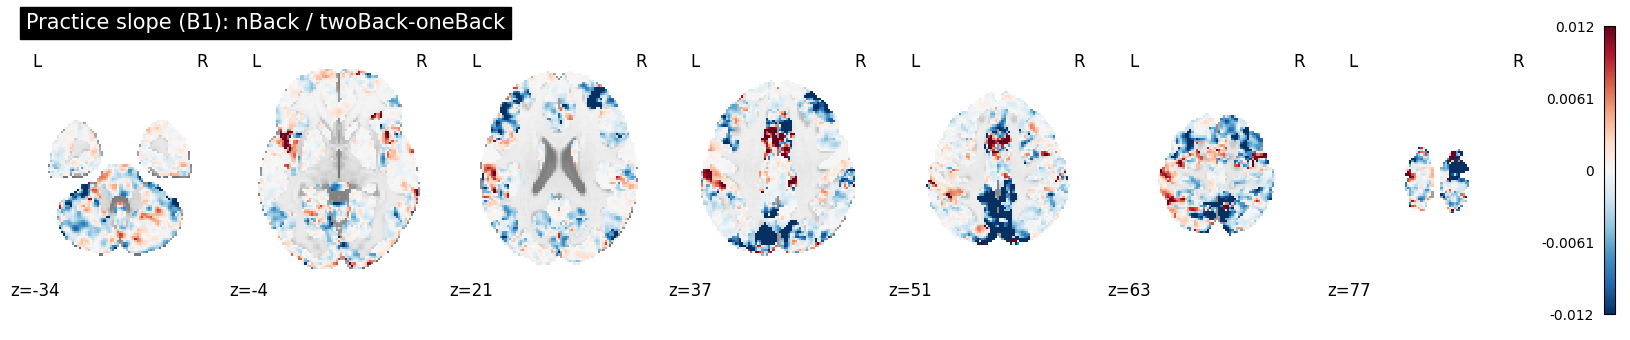

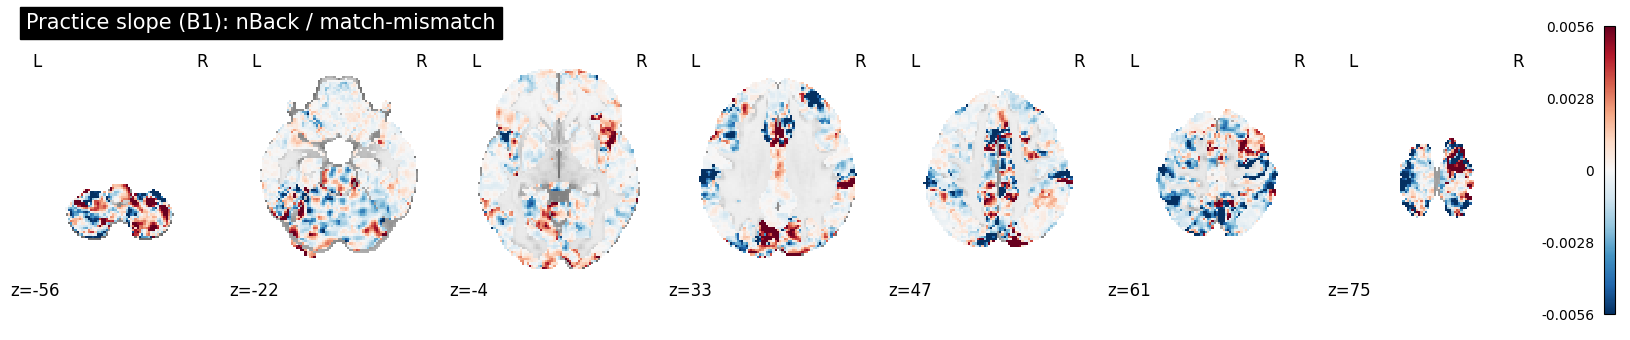

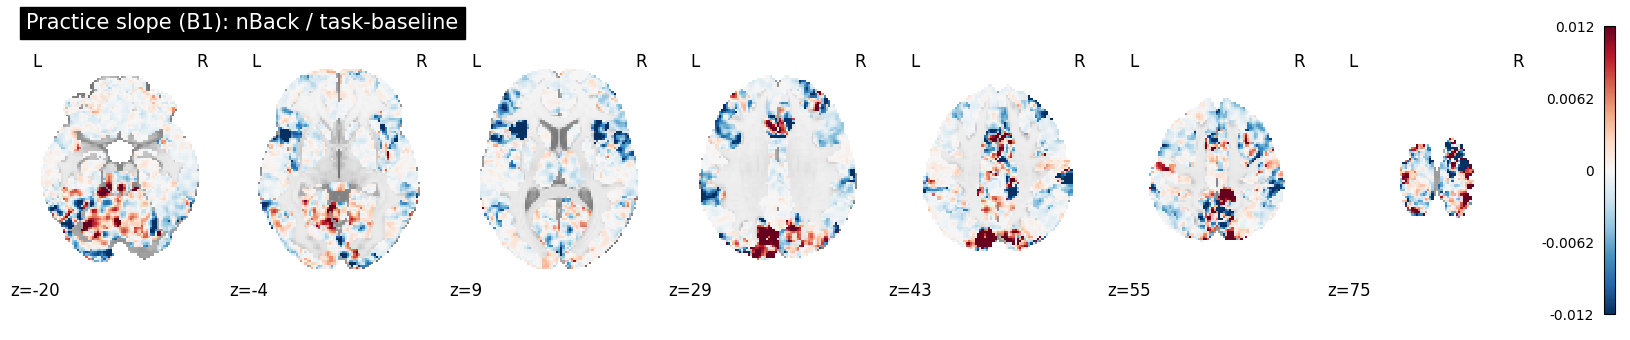

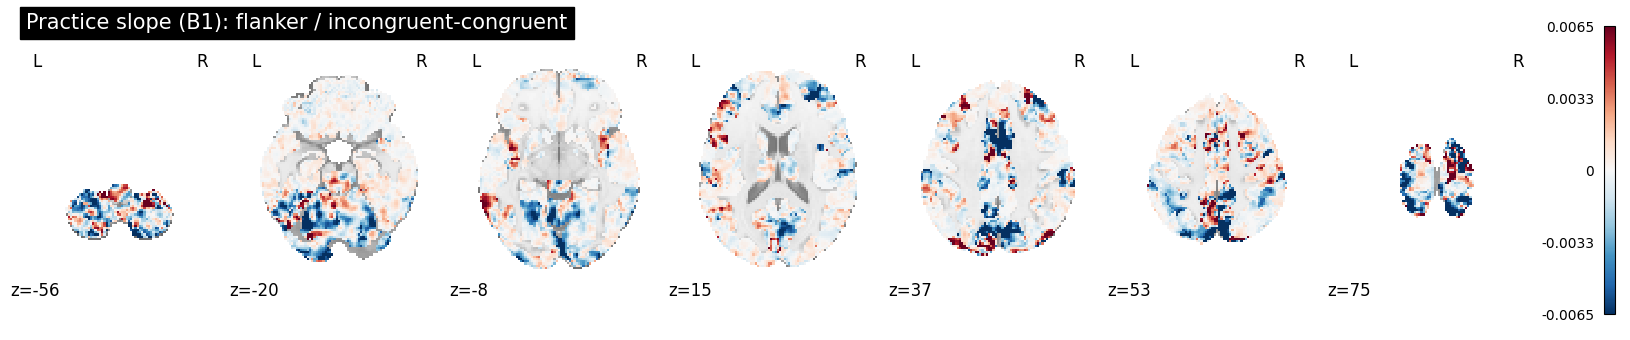

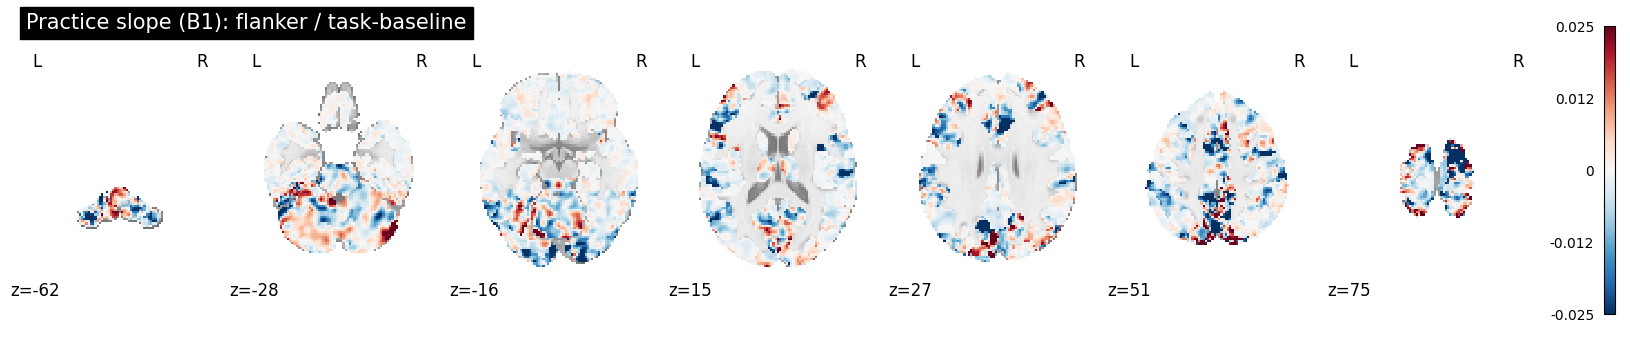

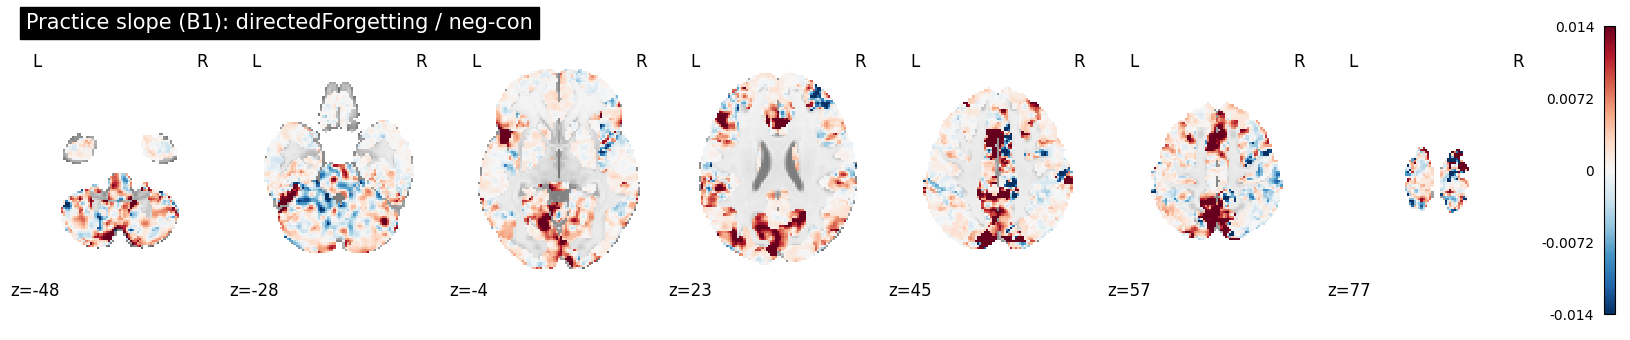

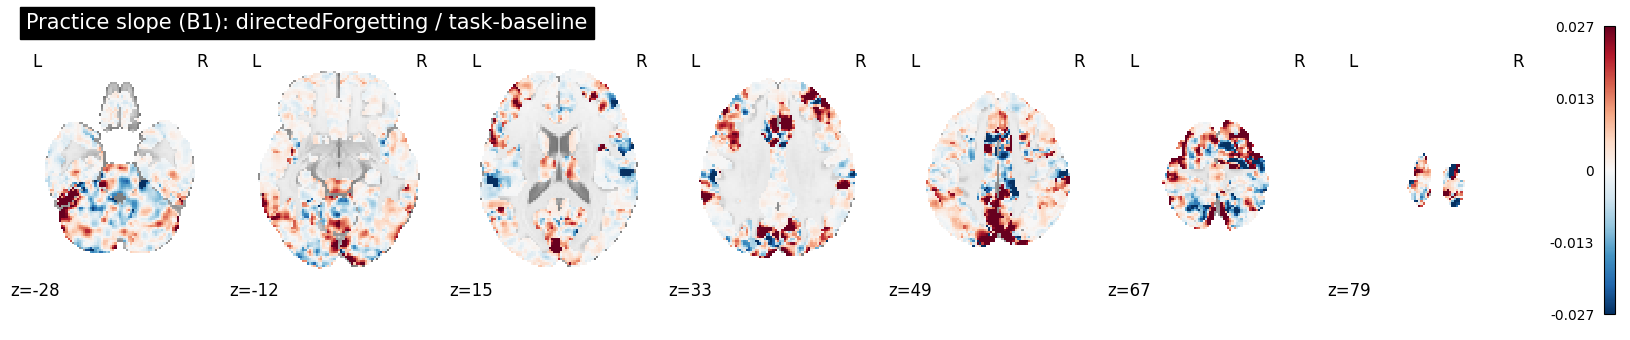

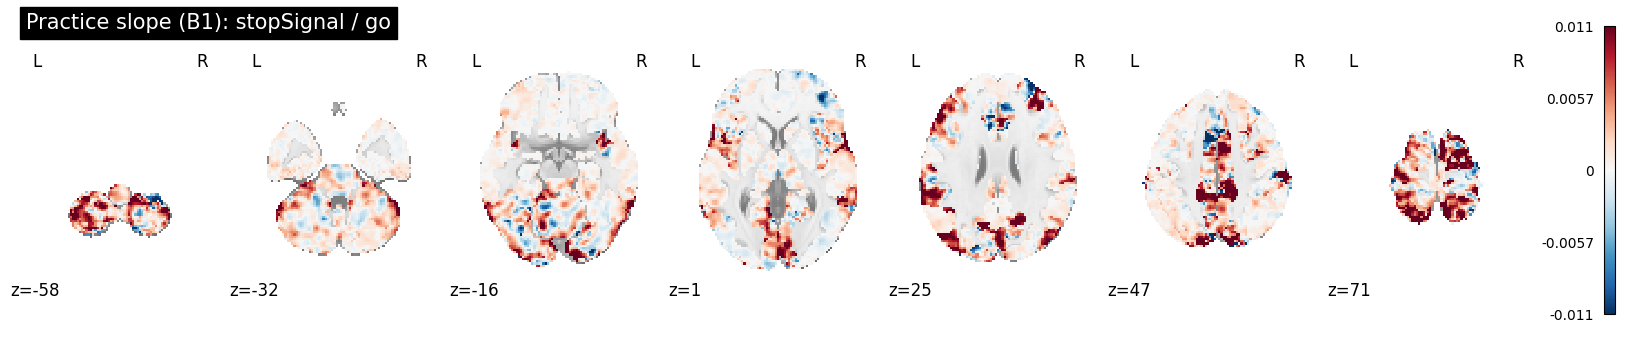

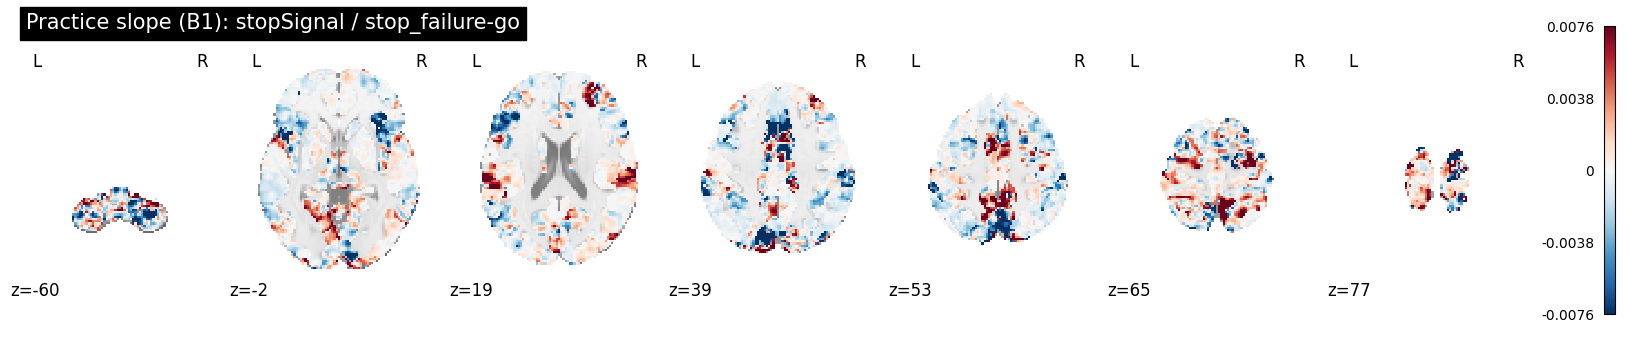

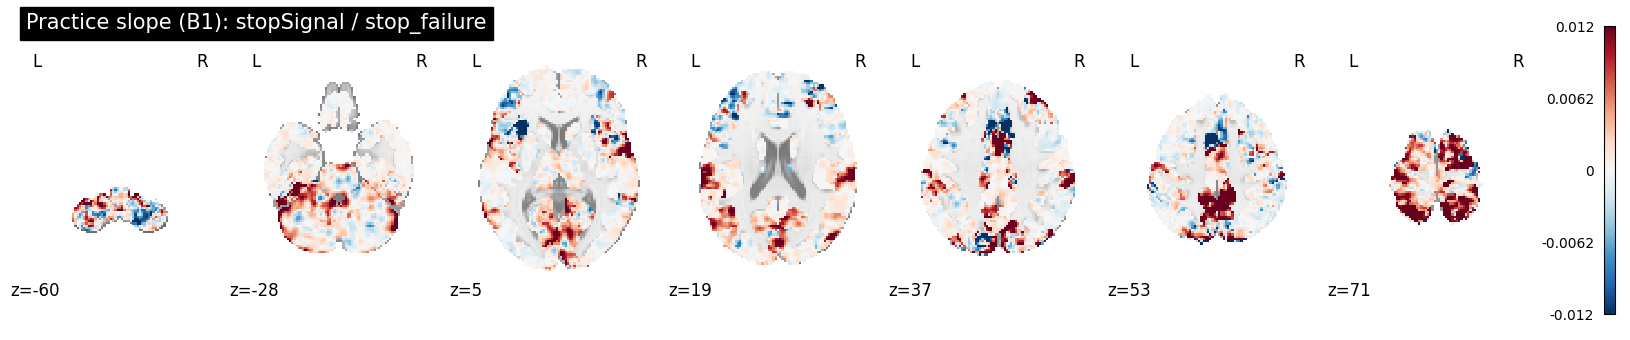

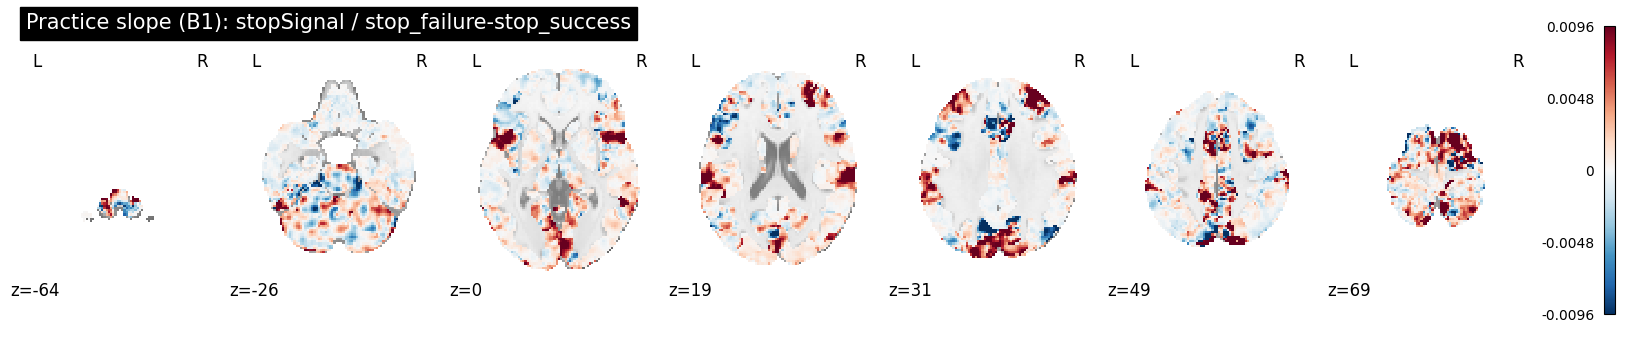

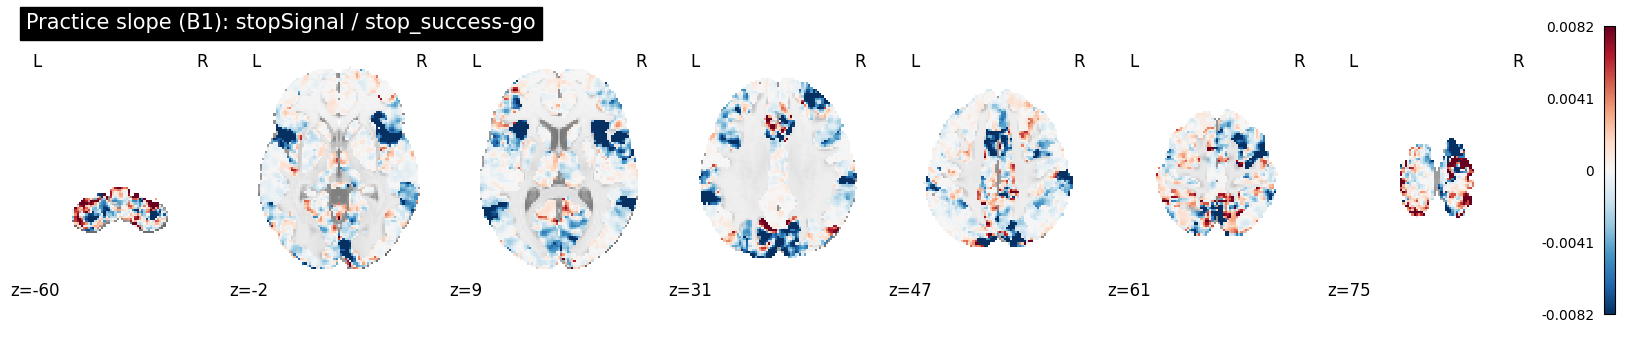

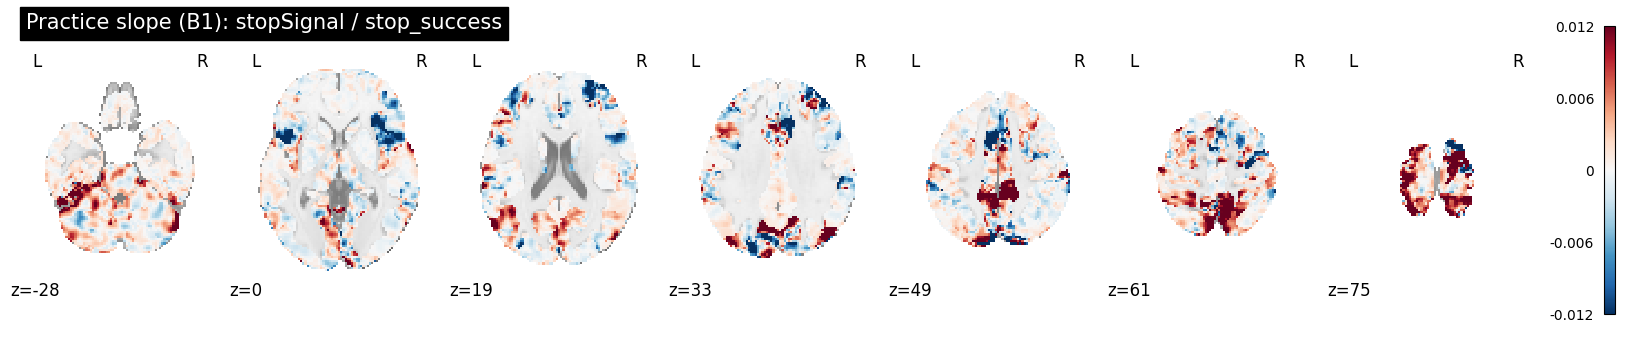

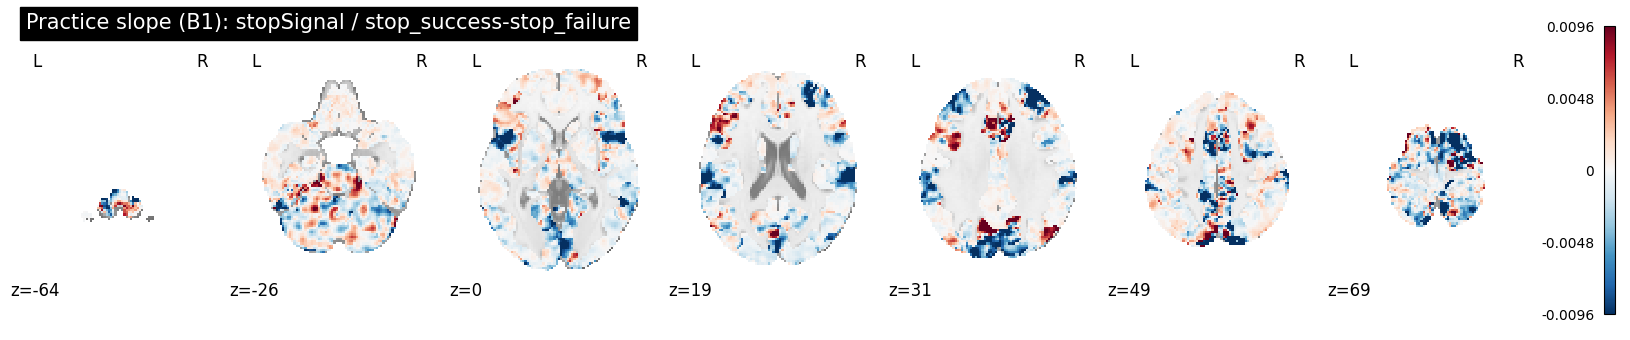

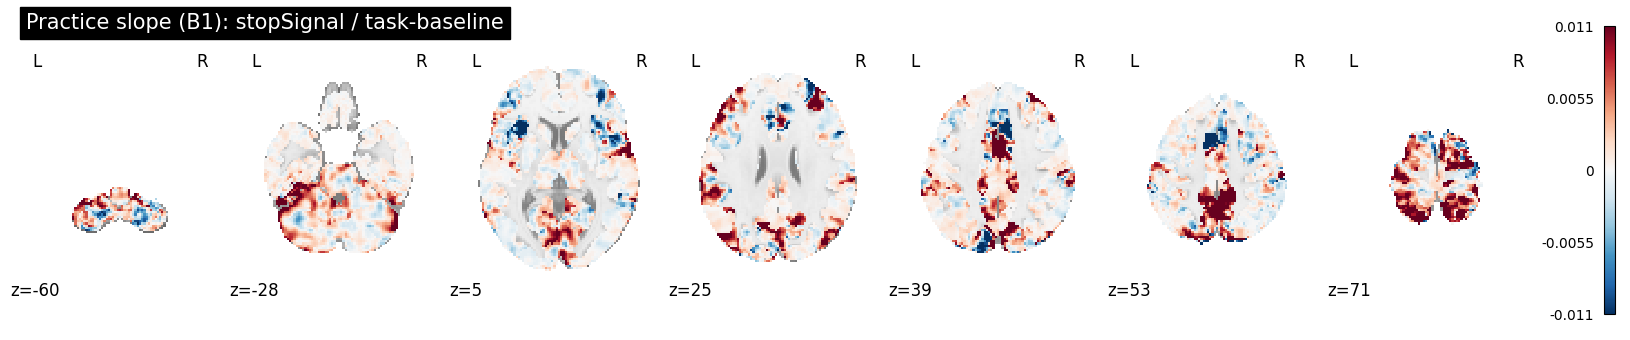

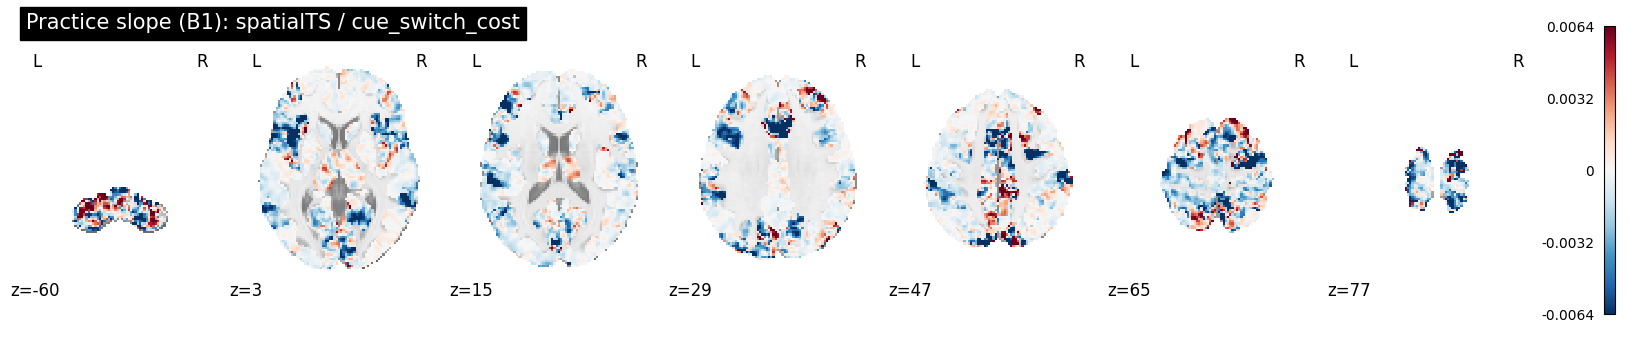

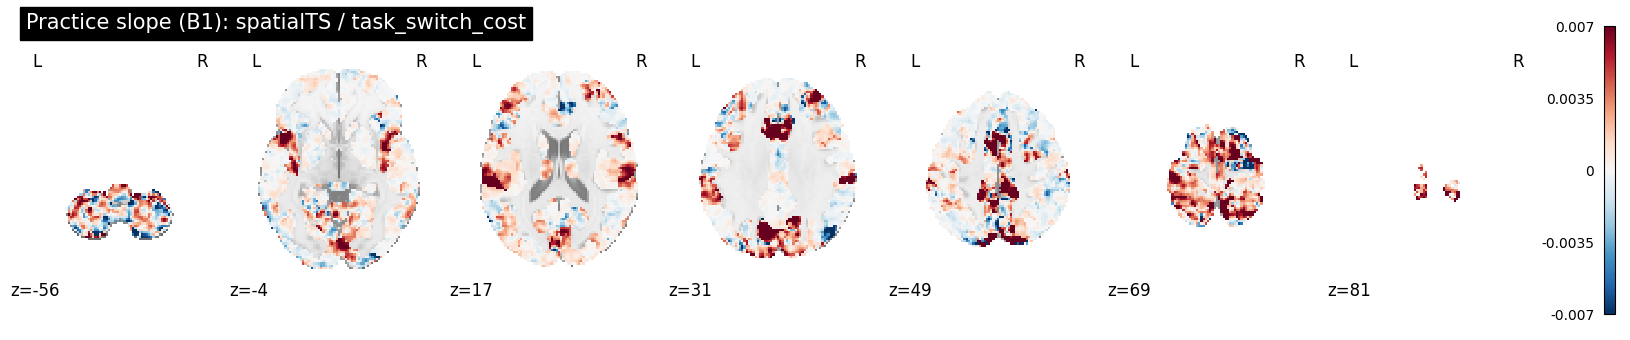

In [ ]:
for task, contrast in full_tc_pairs:
    slope_data = slopes_by_tc[(task, contrast)]
    slope_img = masker.inverse_transform(slope_data)
    vmax = np.percentile(np.abs(slope_data), 95)
    display = plotting.plot_stat_map(
        slope_img, display_mode="z", cut_coords=7,
        symmetric_cbar=True,
        vmax=vmax,
        title=f"Practice slope (B1): {task} / {contrast}",
        colorbar=True
    )
    display.savefig(ALIGN_DIR / f"slope_{task}__{contrast}.png".replace("/", "-"), dpi=120)
    plotting.show()

In [ ]:
# t-stat of each voxel slope
from scipy.stats import ttest_1samp

for task, contrast in full_tc_pairs:
    subj_slopes = subj_slopes_by_tc[(task, contrast)]  # (n_subjects, n_voxels)
    t_vals, p_vals = ttest_1samp(subj_slopes, popmean=0, axis=0)

    slope_data = slopes_by_tc[(task, contrast)].copy()
    slope_data[p_vals > 0.05] = 0

    slope_img = masker.inverse_transform(slope_data)
    vmax = np.percentile(np.abs(slopes_by_tc[(task, contrast)]), 95)
    display = plotting.plot_stat_map(
        slope_img, display_mode="z", cut_coords=7,
        symmetric_cbar=True, vmax=vmax,
        title=f"Practice slope (B1, p<.05 uncorr): {task} / {contrast}",
        colorbar=True
    )
    plotting.show()

### 4b. ISC per encounter

Compute pairwise ISC using only the contrast maps from each encounter.
If ISC increases across encounters, subjects are converging toward more similar neural representations with practice.

In [ ]:
def spatial_corr(a, b):
    """Pearson correlation between two (n_voxels,) spatial maps."""
    a = a - a.mean(); b = b - b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return np.dot(a, b) / (denom + 1e-10)

enc_strs = [f'{e:02d}' for e in range(1, 6)]
enc_nums = list(range(1, 6))

isc_tc_enc = {}
for task, contrast in full_tc_pairs:
    isc_tc_enc[(task, contrast)] = {}
    for enc in enc_strs:
        pair_r = []
        for s1, s2 in pair_labels:
            a = structured[s1][task][contrast][enc]
            b = structured[s2][task][contrast][enc]
            pair_r.append(spatial_corr(a, b))
        isc_tc_enc[(task, contrast)][enc] = np.mean(pair_r)

for task, contrast in full_tc_pairs:
    vals = [isc_tc_enc[(task, contrast)][e] for e in enc_strs]
    print(f"{task}/{contrast}: " + "  ".join(f"enc{i+1}={v:.3f}" for i, v in enumerate(vals)))

In [ ]:
tasks_in_full = list(dict.fromkeys(t for t, c in full_tc_pairs))

fig, axes = plt.subplots(len(tasks_in_full), 1, figsize=(8, 4 * len(tasks_in_full)))
if len(tasks_in_full) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks_in_full):
    contrasts_this_task = [c for t, c in full_tc_pairs if t == task]
    for contrast in contrasts_this_task:
        vals = [isc_tc_enc[(task, contrast)][e] for e in enc_strs]
        ax.plot(enc_nums, vals, marker='o', label=contrast)
    ax.set_title(task)
    ax.set_xlabel('Encounter')
    ax.set_ylabel('Mean spatial ISC (Pearson r)')
    ax.set_xticks(enc_nums)
    ax.legend(fontsize=8, loc='best')

plt.suptitle('Spatial ISC per encounter, per task/contrast (aligned data)', y=1.01)
plt.tight_layout()
plt.savefig(ALIGN_DIR / "isc_per_encounter_per_contrast.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Main contrasts only (exclude task-baseline and match-mismatch)
fig, axes = plt.subplots(len(tasks_in_full), 1, figsize=(8, 4 * len(tasks_in_full)))
if len(tasks_in_full) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks_in_full):
    contrasts_this_task = [c for t, c in full_tc_pairs if t == task]
    for contrast in contrasts_this_task:
        if contrast in ["task-baseline", "match-mismatch"]:
            continue
        vals = [isc_tc_enc[(task, contrast)][e] for e in enc_strs]
        ax.plot(enc_nums, vals, marker='o', label=contrast)
    ax.set_title(task)
    ax.set_xlabel('Encounter')
    ax.set_ylabel('Mean spatial ISC (Pearson r)')
    ax.set_xticks(enc_nums)
    ax.legend(fontsize=8, loc='best')

plt.suptitle('Spatial ISC per encounter, per task/contrast (aligned data)', y=1.01)
plt.tight_layout()
plt.savefig(ALIGN_DIR / "isc_per_encounter_per_contrast_mains.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Pairwise ISC per encounter for selected task/contrasts
tasks_to_plot = {
    "stopSignal": 'stop_failure-go',
    "goNogo": "nogo_success-go",
    "nBack": "twoBack-oneBack",
    "directedForgetting": "neg-con",
    "cuedTS": 'task_switch_cue_switch-task_stay_cue_stay',
    "spatialTS": 'task_switch_cue_switch-task_stay_cue_stay',
    "shapeMatching": "main_vars",
    "flanker": "incongruent-congruent",
}

for SELECTED_TASK in tasks_to_plot:
    for SELECTED_CONTRAST in tasks_to_plot[SELECTED_TASK]:
        pairs = list(combinations(SUBJECTS, 2))
        fig, ax = plt.subplots(figsize=(8, 4))

        for s1, s2 in pairs:
            if SELECTED_CONTRAST not in structured[s1][SELECTED_TASK].keys():
                continue
            vals = []
            for enc in enc_strs:
                v1 = structured[s1][SELECTED_TASK][SELECTED_CONTRAST][enc]
                v2 = structured[s2][SELECTED_TASK][SELECTED_CONTRAST][enc]
                vals.append(pearsonr(v1, v2)[0])
            ax.plot(enc_nums, vals, marker='o', label=f"{s1} × {s2}")

        ax.set_title(f"Pairwise spatial ISC: {SELECTED_TASK} / {SELECTED_CONTRAST}")
        ax.set_xlabel("Encounter")
        ax.set_ylabel("Spatial ISC (Pearson r)")
        ax.set_xticks(enc_nums)
        ax.legend(fontsize=8, loc='best')
        plt.tight_layout()
        plt.savefig(ALIGN_DIR / f"isc_pairwise_{SELECTED_TASK}__{SELECTED_CONTRAST}.png", dpi=150, bbox_inches='tight')
        plt.show()